# Problem Formulation & Exploratory Data Analysis

[Github](https://github.com/dincerefe/machinelearning_yzm2011/tree/main)

## 1. Problem Statement

**1.1** Flight delays cause huge costs for airlines and make passengers’ experience with the airline worse. In this project, I will analyze and predict how much a flight will be delayed so a customer can know how much he will wait.

**1.2** 
Passengers can benefit from this. Thanks to the predictions, they can know in advance how much a flight will be delayed. Additionally, airlines can estimate how much delay a flight will have before planning it and calculate their costs according to delay.

**1.3** My prediction target is `departure_delay_min`.

**1.4** 
I can predict `departure_delay_min` with regression then classify it with that result.


## 2. Dataset Description

**2.1** The data was scraped using Python scripts from flightera.net and merged with hourly climate data obtained from the openmeteo. Also, the aircraft types were scraped from flightaware.com.

**2.2** The dataset consists of approximately 660,000 completed flights and contains 38 distinct features.

**2.3**


- `departure_delay_min`: The exact duration of the departure delay in minutes.
- `status_category`: Categorical label indicating whether the flight was 'Early', 'On Time', 'Delayed', or 'Cancelled'.
- `airline`: The name of the operating carrier (e.g., Turkish Airlines, Pegasus).
- `flight_number`: The unique alphanumeric identifier for the flight.
- `aircraft_type`: The specific model of the aircraft used for the flight (e.g., B737-800, A321).
- `is_domestic`: Binary indicator (1 for domestic flights, 0 for international).
- `status`: Raw flight status fetched from the source (e.g., Landed).
- `departure_airport`: The IATA/ICAO code of the origin airport.
- `departure_city`: The city where the origin airport is located.
- `arrival_airport`: The IATA/ICAO code of the destination airport.
- `arrival_info`: Detailed information or name of the destination airport.
- `date`: The scheduled date of the flight (YYYY-MM-DD).
- `scheduled_departure`: The initially planned time of takeoff.
- `actual_departure`: The real, recorded time the aircraft took off.
- `arrival_time`: The recorded time the aircraft landed at the destination.
- `flight_duration`: The total time spent in the air (raw string format, e.g., "1h 30m").
- `actual_flight_duration_min`: Calculated exact flight duration converted into minutes.
- `average_flight_duration_min`: The historical average flight time for that specific route.
- `arrival_delay_min`: The exact delay experienced upon landing, in minutes.
- `month`: The month of the flight (1-12).
- `day_name`: The name of the day (e.g., Monday).
- `day_of_week`: Numerical representation of the day of the week.
- `departure_hour`: The specific hour the flight was scheduled to depart (0-23).
- `time_slot`: Categorical representation of the departure time (e.g., Morning, Afternoon, Evening, Night).
- `dep_temperature`: Temperature at the departure airport (°C).
- `dep_humidity`: Relative humidity at the departure airport (%).
- `dep_precipitation_mm`: Amount of rainfall/precipitation at the departure airport (mm).
- `dep_wind_speed`: Wind speed at the time of departure.
- `dep_wind_gust`: Maximum wind gusts recorded at departure.
- `dep_visibility_min_m`: Minimum visibility distance at departure (meters).
- `dep_cloud_cover`: Percentage of cloud cover at the departure location.

**2.4** The data is mostly scraped from flightera.net so if their data is incorrect my data is also incorrect. And also some airports doesn't have detailed weather forecast because of their location.

## 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../turkiye_ucuslari_final.csv')


In [2]:
df.head(10)

,date,departure_airport,departure_city,arrival_airport,arrival_info,airline,flight_number,scheduled_departure,actual_departure,arrival_time,...,arr_temperature,arr_humidity,arr_precipitation_mm,arr_wind_speed,arr_wind_gust,arr_visibility_min_m,arr_cloud_cover,actual_flight_duration_min,average_flight_duration_min,arrival_delay_min
0,2024-01-01,KYA,Konya,DUS,Dusseldorf(DUS / EDDL),SunExpress,XQ1326,04:30,04:46,06:15,...,6.5,84.0,0.5,24.6,47.5,NaN,NaN,208.0,207.5,16.5
1,2024-01-01,KYA,Konya,SAW,Istanbul(SAW / LTFJ),Turkish Airlines,TK7283,08:20,12:13,13:07,...,13.9,65.0,0.0,11.9,24.5,NaN,97.0,54.0,55.0,232.0
2,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK2033,09:50,09:57,11:20,...,11.9,83.0,0.0,14.2,25.9,NaN,62.0,90.0,60.0,37.0
3,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK2037,16:20,16:21,17:34,...,14.4,76.0,0.0,16.1,29.9,NaN,87.0,73.0,60.0,14.0
4,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK6951,17:05,17:09,18:11,...,13.4,80.0,0.0,18.0,31.0,NaN,97.0,62.0,60.0,6.0
5,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK2039,21:50,07:45,00:25,...,8.8,94.0,0.0,7.8,12.2,NaN,62.0,NaN,60.0,NaN
6,2024-01-01,KYA,Konya,SAW,Istanbul(SAW / LTFJ),Pegasus,PC2701,22:50,23:46,00:55,...,9.8,85.0,0.0,9.0,15.5,NaN,55.0,69.0,55.0,70.0
7,2024-01-01,KYA,Konya,SAW,Istanbul(SAW / LTFJ),Pegasus,PC2701,22:50,23:46,00:55,...,9.8,85.0,0.0,9.0,15.5,NaN,55.0,69.0,55.0,70.0
8,2024-01-01,KYA,Konya,SAW,Istanbul(SAW / LTFJ),Pegasus,PC4031,07:00,06:59,08:05,...,9.1,79.0,0.0,9.2,16.6,NaN,87.0,66.0,55.0,10.0
9,2024-01-01,KYA,Konya,SAW,Istanbul(SAW / LTFJ),Turkish Airlines,TK7283,08:20,08:19,09:18,...,9.1,79.0,0.0,9.4,16.2,NaN,68.0,58.0,55.0,2.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668274 entries, 0 to 668273
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   date                         668274 non-null  str    
 1   departure_airport            668274 non-null  str    
 2   departure_city               668274 non-null  str    
 3   arrival_airport              668274 non-null  str    
 4   arrival_info                 668274 non-null  str    
 5   airline                      668274 non-null  str    
 6   flight_number                668274 non-null  str    
 7   scheduled_departure          668274 non-null  str    
 8   actual_departure             653767 non-null  str    
 9   arrival_time                 653767 non-null  str    
 10  flight_duration              662115 non-null  str    
 11  status                       660718 non-null  str    
 12  status_category              660718 non-null  str    
 13  departure_

In [4]:
df.describe(include=['object'])

C:\Users\dince\AppData\Local\Temp\ipykernel_6612\3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,date,departure_airport,departure_city,arrival_airport,arrival_info,airline,flight_number,scheduled_departure,actual_departure,arrival_time,flight_duration,status,status_category,aircraft_type,day_name,time_slot
count,668274,668274,668274,668274,668274,668274,668274,668274,653767,653767,662115,660718,660718,668274,668274,668274
unique,369,50,50,447,574,223,7853,646,1440,1440,1210,6,3,8,7,4
top,2024-06-15,IST,Istanbul,IST,Istanbul(IST / LTFM),Turkish Airlines,XQ9283,08:00,08:26,13:20,54m,Landed,Delayed,B737-800,Sunday,Sabah
freq,2387,222161,222161,67312,67035,282842,774,7395,905,833,6869,652577,396314,154383,98252,221439


In [5]:
df.describe()

,departure_delay_min,is_domestic,month,day_of_week,departure_hour,dep_temperature,dep_humidity,dep_precipitation_mm,dep_wind_speed,dep_wind_gust,...,arr_temperature,arr_humidity,arr_precipitation_mm,arr_wind_speed,arr_wind_gust,arr_visibility_min_m,arr_cloud_cover,actual_flight_duration_min,average_flight_duration_min,arrival_delay_min
count,653767.000000,668274.000000,668274.000000,668274.000000,668274.000000,668274.000000,668274.000000,668274.000000,668274.000000,668274.000000,...,666220.000000,666220.000000,666220.000000,666220.000000,666220.000000,0.0,90464.000000,662115.000000,668272.000000,647637.000000
mean,29.261921,0.437096,6.553478,3.032747,12.832156,17.406594,66.974712,0.079291,11.394672,24.698690,...,16.445895,67.561498,0.088024,11.125528,23.484530,NaN,63.502896,146.676965,143.290621,31.074351
std,55.228203,0.496028,3.319822,2.005681,6.107893,8.823604,20.150254,0.454908,6.641525,12.633536,...,9.264781,20.842446,0.471998,6.769005,12.413873,NaN,41.208921,122.723862,115.568503,61.597931
min,-720.000000,0.000000,1.000000,0.000000,0.000000,-18.800000,4.000000,0.000000,0.000000,0.700000,...,-32.300000,3.000000,0.000000,0.000000,0.700000,NaN,0.000000,0.000000,6.000000,-1405.000000
25%,10.000000,0.000000,4.000000,1.000000,8.000000,10.700000,54.000000,0.000000,6.200000,14.800000,...,9.800000,54.000000,0.000000,6.000000,13.700000,NaN,17.000000,65.000000,64.000000,9.000000
50%,19.000000,0.000000,7.000000,3.000000,13.000000,17.100000,70.000000,0.000000,10.200000,22.700000,...,16.000000,71.000000,0.000000,9.700000,21.200000,NaN,89.000000,108.000000,105.000000,21.000000
75%,35.000000,1.000000,9.000000,5.000000,18.000000,24.400000,83.000000,0.000000,15.600000,33.100000,...,23.200000,85.000000,0.000000,15.100000,31.000000,NaN,100.000000,195.000000,193.000000,38.000000
max,720.000000,1.000000,12.000000,6.000000,23.000000,43.600000,100.000000,20.100000,50.400000,103.300000,...,50.800000,100.000000,31.300000,57.000000,102.200000,NaN,100.000000,1439.000000,828.000000,1483.000000


## 4. Data Cleaning

                             Missing Count  Missing Percentage (%)
arr_visibility_min_m                668274                  100.00
dep_visibility_min_m                668274                  100.00
arr_cloud_cover                     577810                   86.46
dep_cloud_cover                     575792                   86.16
arrival_delay_min                    20637                    3.09
actual_departure                     14507                    2.17
arrival_time                         14507                    2.17
departure_delay_min                  14507                    2.17
status_category                       7556                    1.13
status                                7556                    1.13
flight_duration                       6159                    0.92
actual_flight_duration_min            6159                    0.92
arr_humidity                          2054                    0.31
arr_temperature                       2054                    

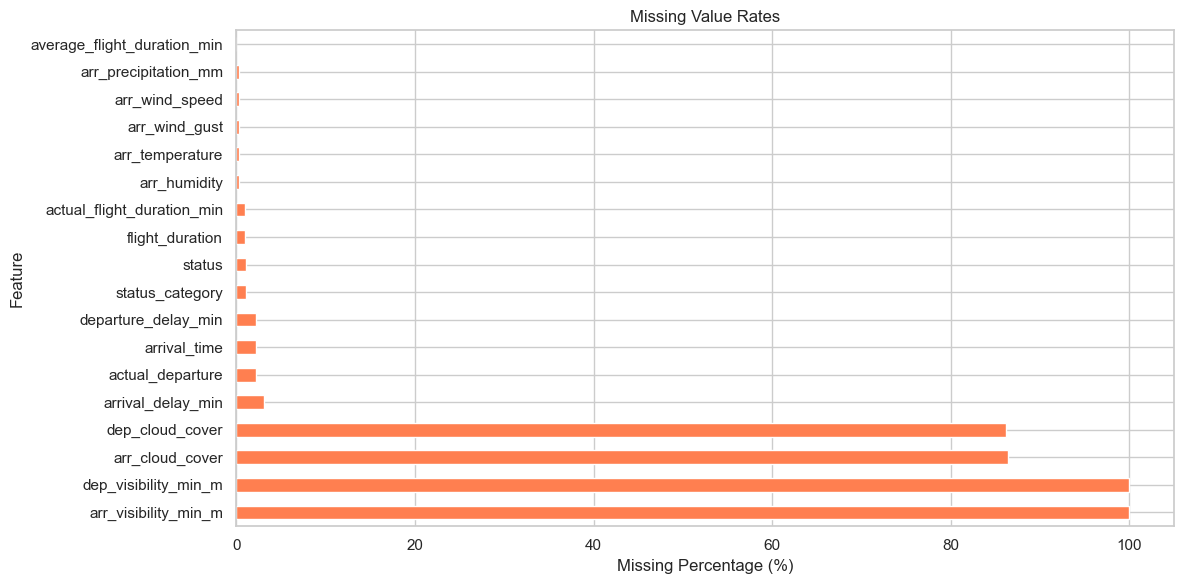

In [6]:
# Extract missing values info
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(12, 6))
missing_df['Missing Percentage (%)'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_ylabel('Feature')
ax.set_title('Missing Value Rates')
plt.tight_layout()
plt.show()


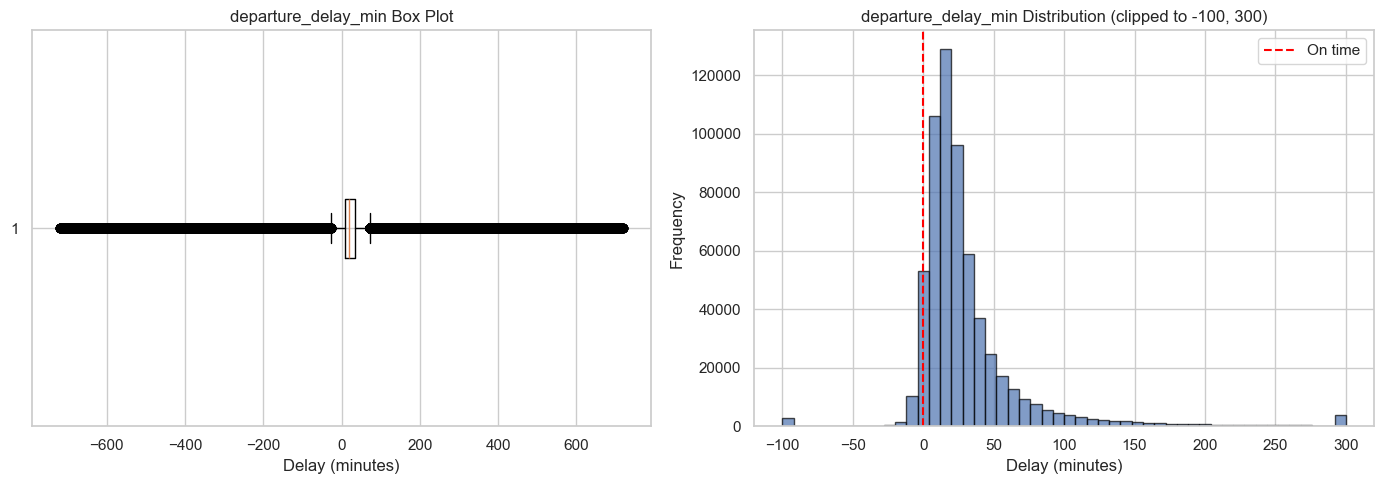

Missing Values per Column:
 flight_duration                5730
arr_temperature                1907
arr_humidity                   1907
arr_precipitation_mm           1907
arr_wind_speed                 1907
arr_wind_gust                  1907
actual_flight_duration_min     5730
average_flight_duration_min       2
arrival_delay_min              5730
dtype: int64


In [7]:

df.dropna(subset=['status_category'], inplace=True)
df.drop(columns=['dep_visibility_min_m', 'arr_visibility_min_m', 'dep_cloud_cover', 'arr_cloud_cover'], inplace=True)

# Impute missing weather data with median
for col in ['dep_temperature', 'dep_wind_speed']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Duplicate Rows
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)

# Datetimes
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Outliers
Q1 = df['departure_delay_min'].quantile(0.25)
Q3 = df['departure_delay_min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['departure_delay_min'] < lower_bound) | (df['departure_delay_min'] > upper_bound)]

# Derived Metrics & Data Corrections
df['is_cancelled'] = np.where(df['status'] == 'Cancelled', 1, 0)
df['route'] = df['departure_airport'] + " -> " + df['arrival_airport']


# Correct Adana
df.loc[df['arrival_airport'] == 'ADA', 'is_domestic'] = 1
df.loc[df['departure_airport'] == 'ADA', 'is_domestic'] = 1

time_slot_mapping = {
    'Sabah': 'Morning',
    'Ogle': 'Afternoon',
    'Aksam': 'Evening',
    'Gece': 'Night'
}

# 
df['time_slot'] = df['time_slot'].replace(time_slot_mapping)

# Change Categories
cancel_mask = df['status_category'].isin(['Cancelled', 'Unknown']) | df['status'].isin(['Cancelled'])
df.loc[(df['arrival_delay_min'] > 15) & (~cancel_mask), 'status_category'] = 'Delayed'
df.loc[(df['arrival_delay_min'] < -15) & (~cancel_mask), 'status_category'] = 'Early'
df.loc[(df['arrival_delay_min'] >= -15) & (df['arrival_delay_min'] <= 15) & (~cancel_mask), 'status_category'] = 'On_Time'
df.loc[cancel_mask, 'status_category'] = 'Cancelled'

df['airline'] = df['airline'].astype(str).str.strip().str.upper()

completed_flights_df = df[df['status_category'] != 'Cancelled'].copy()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['departure_delay_min'].dropna(), vert=False)
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_title('departure_delay_min Box Plot')

# Histogram
axes[1].hist(df['departure_delay_min'].clip(-100, 300), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Delay (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('departure_delay_min Distribution (clipped to -100, 300)')
axes[1].axvline(x=0, color='red', linestyle='--', label='On time')
axes[1].legend()

plt.tight_layout()
plt.show()


missing = completed_flights_df.isnull().sum()
print("Missing Values per Column:\n", missing[missing > 0])



## 5. Univariate Analysis 

TARGET VARIABLE ANALYSIS: departure_delay_min (Delay Minutes)
Mean: 29.31 minutes
Median: 19.00 minutes
Standard Deviation (Std): 55.18
Minimum: -720.00
Maximum: 720.00
Skewness: 1.34
Kurtosis: 58.66

--- Percentiles ---
1%: -11.00
5%: -1.00
25%: 10.00
50%: 19.00
75%: 35.00
95%: 96.00
99%: 228.27


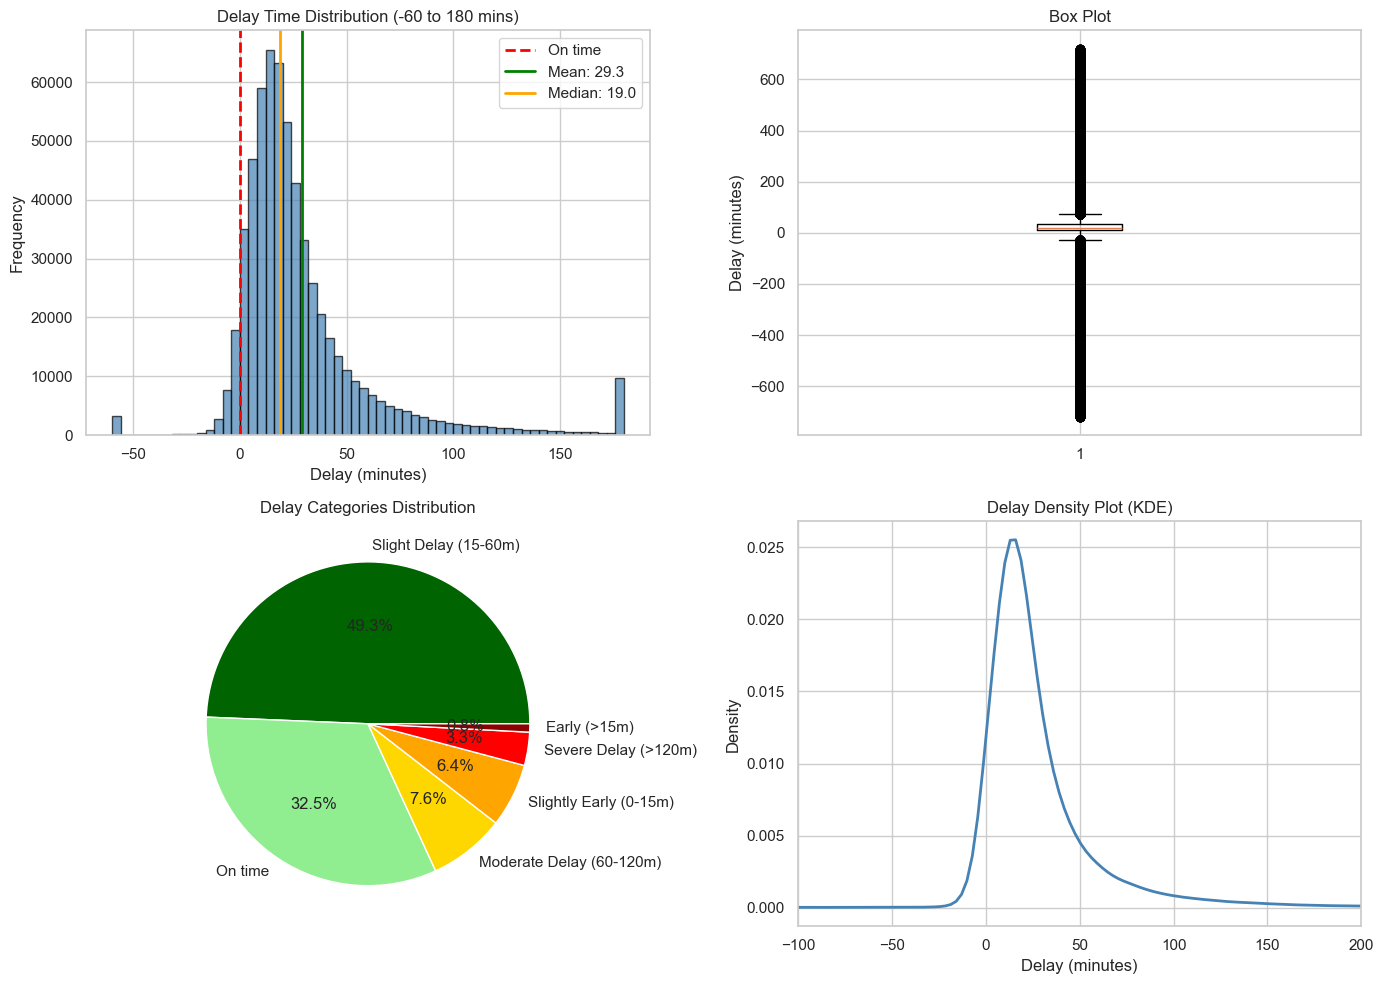

In [8]:
# departure_delay_min
print("=" * 60)
print("TARGET VARIABLE ANALYSIS: departure_delay_min (Delay Minutes)")
print("=" * 60)

delay = completed_flights_df['departure_delay_min']

print(f"Mean: {delay.mean():.2f} minutes")
print(f"Median: {delay.median():.2f} minutes")
print(f"Standard Deviation (Std): {delay.std():.2f}")
print(f"Minimum: {delay.min():.2f}")
print(f"Maximum: {delay.max():.2f}")
print(f"Skewness: {delay.skew():.2f}")
print(f"Kurtosis: {delay.kurtosis():.2f}")

# Percentiles
print(f"\n--- Percentiles ---")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"{p}%: {delay.quantile(p/100):.2f}")

# Delay Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(delay.clip(-60, 180), bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='On time')
axes[0, 0].axvline(x=delay.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {delay.mean():.1f}')
axes[0, 0].axvline(x=delay.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {delay.median():.1f}')
axes[0, 0].set_xlabel('Delay (minutes)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Delay Time Distribution (-60 to 180 mins)')
axes[0, 0].legend()

#Box Plot
axes[0, 1].boxplot(delay.dropna(), vert=True)
axes[0, 1].set_ylabel('Delay (minutes)')
axes[0, 1].set_title('Box Plot')

# Delay Categories
delay_categories = pd.cut(delay, bins=[-np.inf, -15, 0, 15, 60, 120, np.inf], 
                          labels=['Early (>15m)', 'Slightly Early (0-15m)', 'On time', 
                                  'Slight Delay (15-60m)', 'Moderate Delay (60-120m)', 'Severe Delay (>120m)'])
delay_cats = delay_categories.value_counts()
colors = ['darkgreen', 'lightgreen', 'gold', 'orange', 'red', 'darkred']
axes[1, 0].pie(delay_cats, labels=delay_cats.index, autopct='%1.1f%%', colors=colors)
axes[1, 0].set_title('Delay Categories Distribution')

# KDE Plot
delay.plot(kind='kde', ax=axes[1, 1], color='steelblue', linewidth=2)
axes[1, 1].set_xlabel('Delay (minutes)')
axes[1, 1].set_title('Delay Density Plot (KDE)')
axes[1, 1].set_xlim(-100, 200)

plt.tight_layout()
plt.show()

STATISTICAL SUMMARY OF NUMERICAL VARIABLES
                               Mean  Median     Std    Min     Max  Skewness
departure_delay_min           29.31    19.0   55.18 -720.0   720.0      1.34
departure_hour                12.73    13.0    6.10    0.0    23.0     -0.11
month                          6.54     7.0    3.32    1.0    12.0     -0.04
day_of_week                    3.03     3.0    2.01    0.0     6.0     -0.03
dep_temperature               17.45    17.2    8.82  -18.8    43.6      0.01
dep_humidity                  66.97    70.0   20.12    4.0   100.0     -0.55
dep_precipitation_mm           0.08     0.0    0.45    0.0    20.1     13.88
dep_wind_speed                11.37    10.2    6.62    0.0    50.4      0.75
dep_wind_gust                 24.66    22.7   12.60    0.7   101.5      0.64
arr_temperature               16.44    16.0    9.26  -32.3    50.8      0.05
arr_humidity                  67.56    71.0   20.81    3.0   100.0     -0.65
arr_precipitation_mm           0.

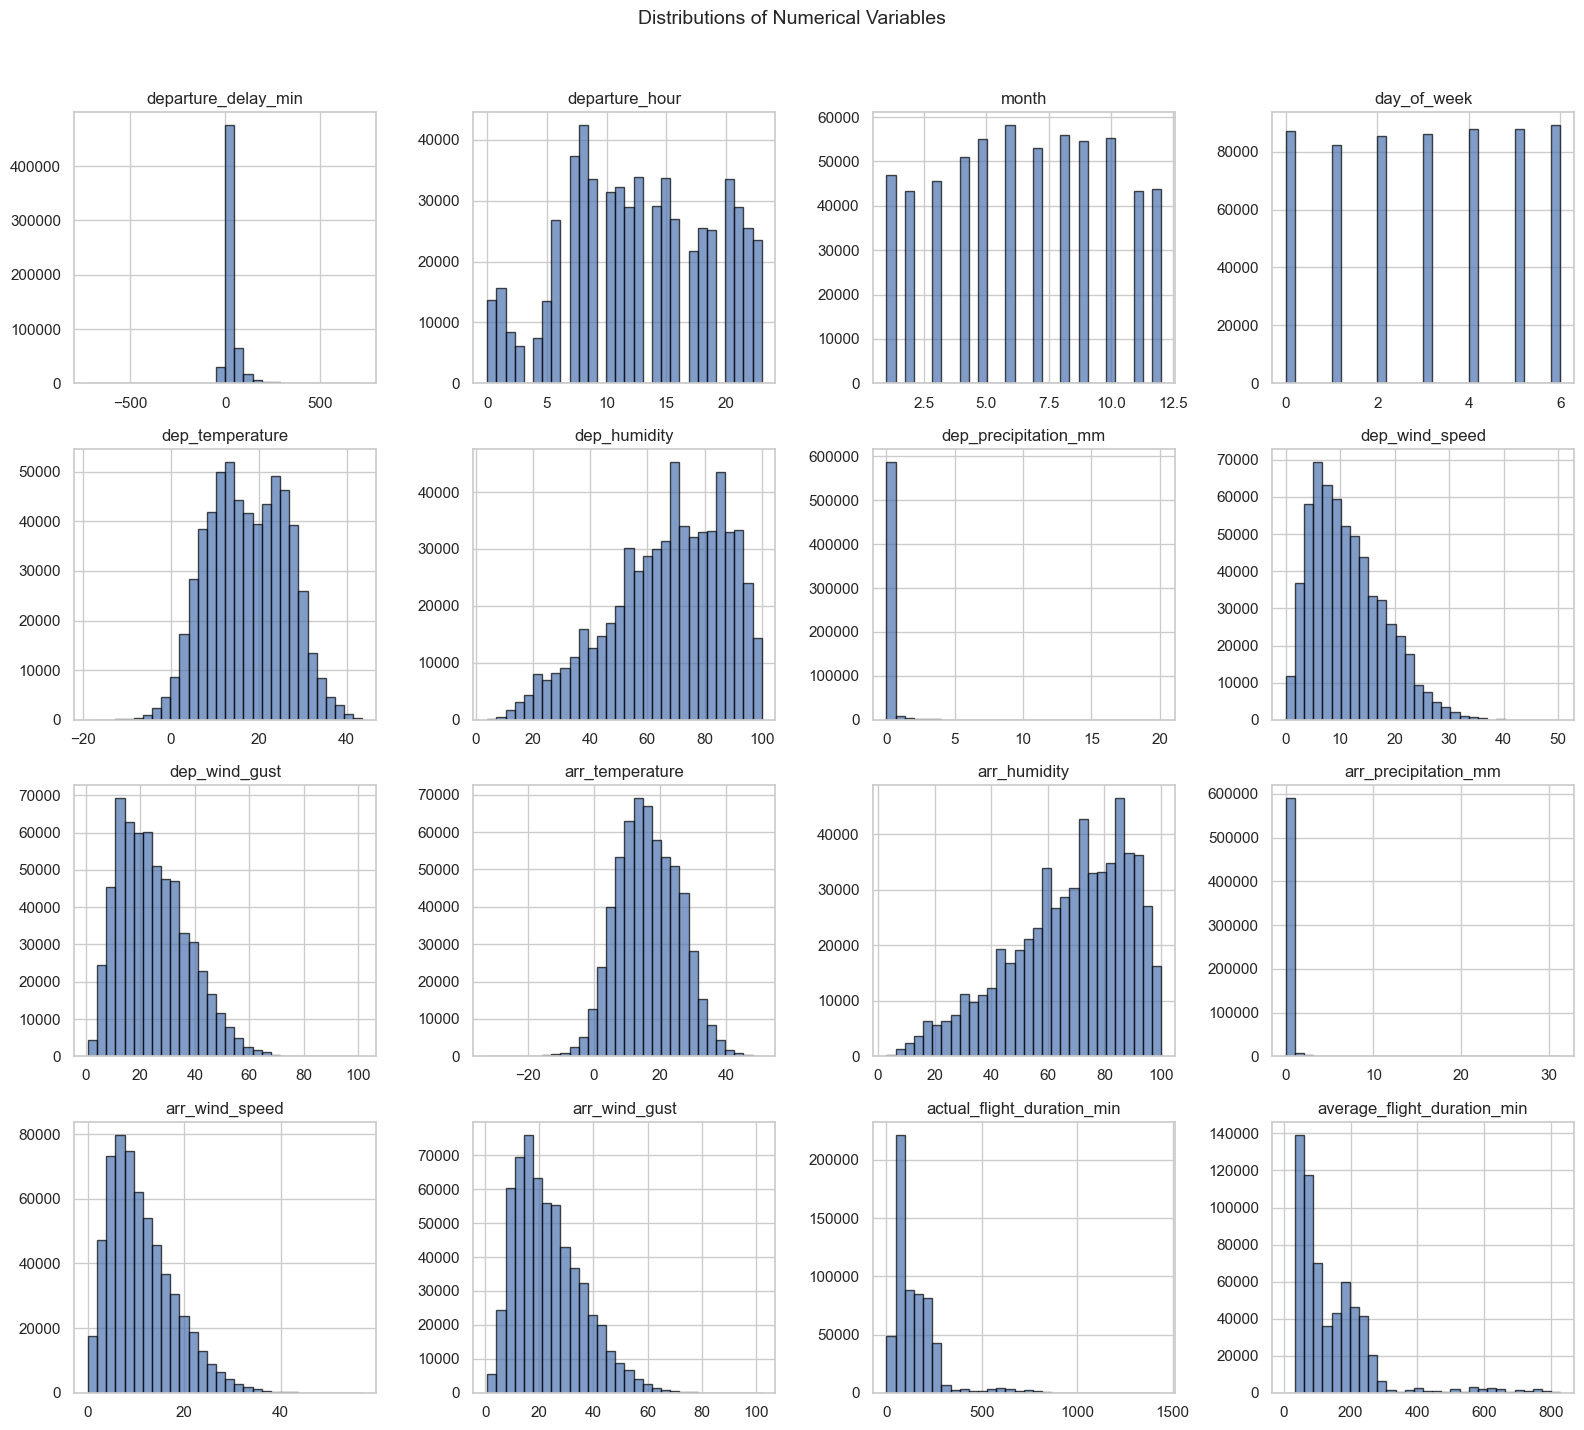

In [9]:
# Numerical variables
numerical_cols = [
    'departure_delay_min', 'departure_hour', 'month', 'day_of_week',
    'dep_temperature', 'dep_humidity', 'dep_precipitation_mm', 
    'dep_wind_speed', 'dep_wind_gust',
    'arr_temperature', 'arr_humidity', 'arr_precipitation_mm', 
    'arr_wind_speed', 'arr_wind_gust',
    'actual_flight_duration_min', 'average_flight_duration_min'
]

# Statistical summary
print("STATISTICAL SUMMARY OF NUMERICAL VARIABLES")
print("=" * 80)

# Calculating statistics and transposing for better readability
stats_df = completed_flights_df[numerical_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew']).T
stats_df.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Skewness']

print(stats_df.round(2))

# Histograms of numerical variables
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].hist(completed_flights_df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        
# Hide empty subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle('Distributions of Numerical Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 6. Bivariate & Multivariate Analysis


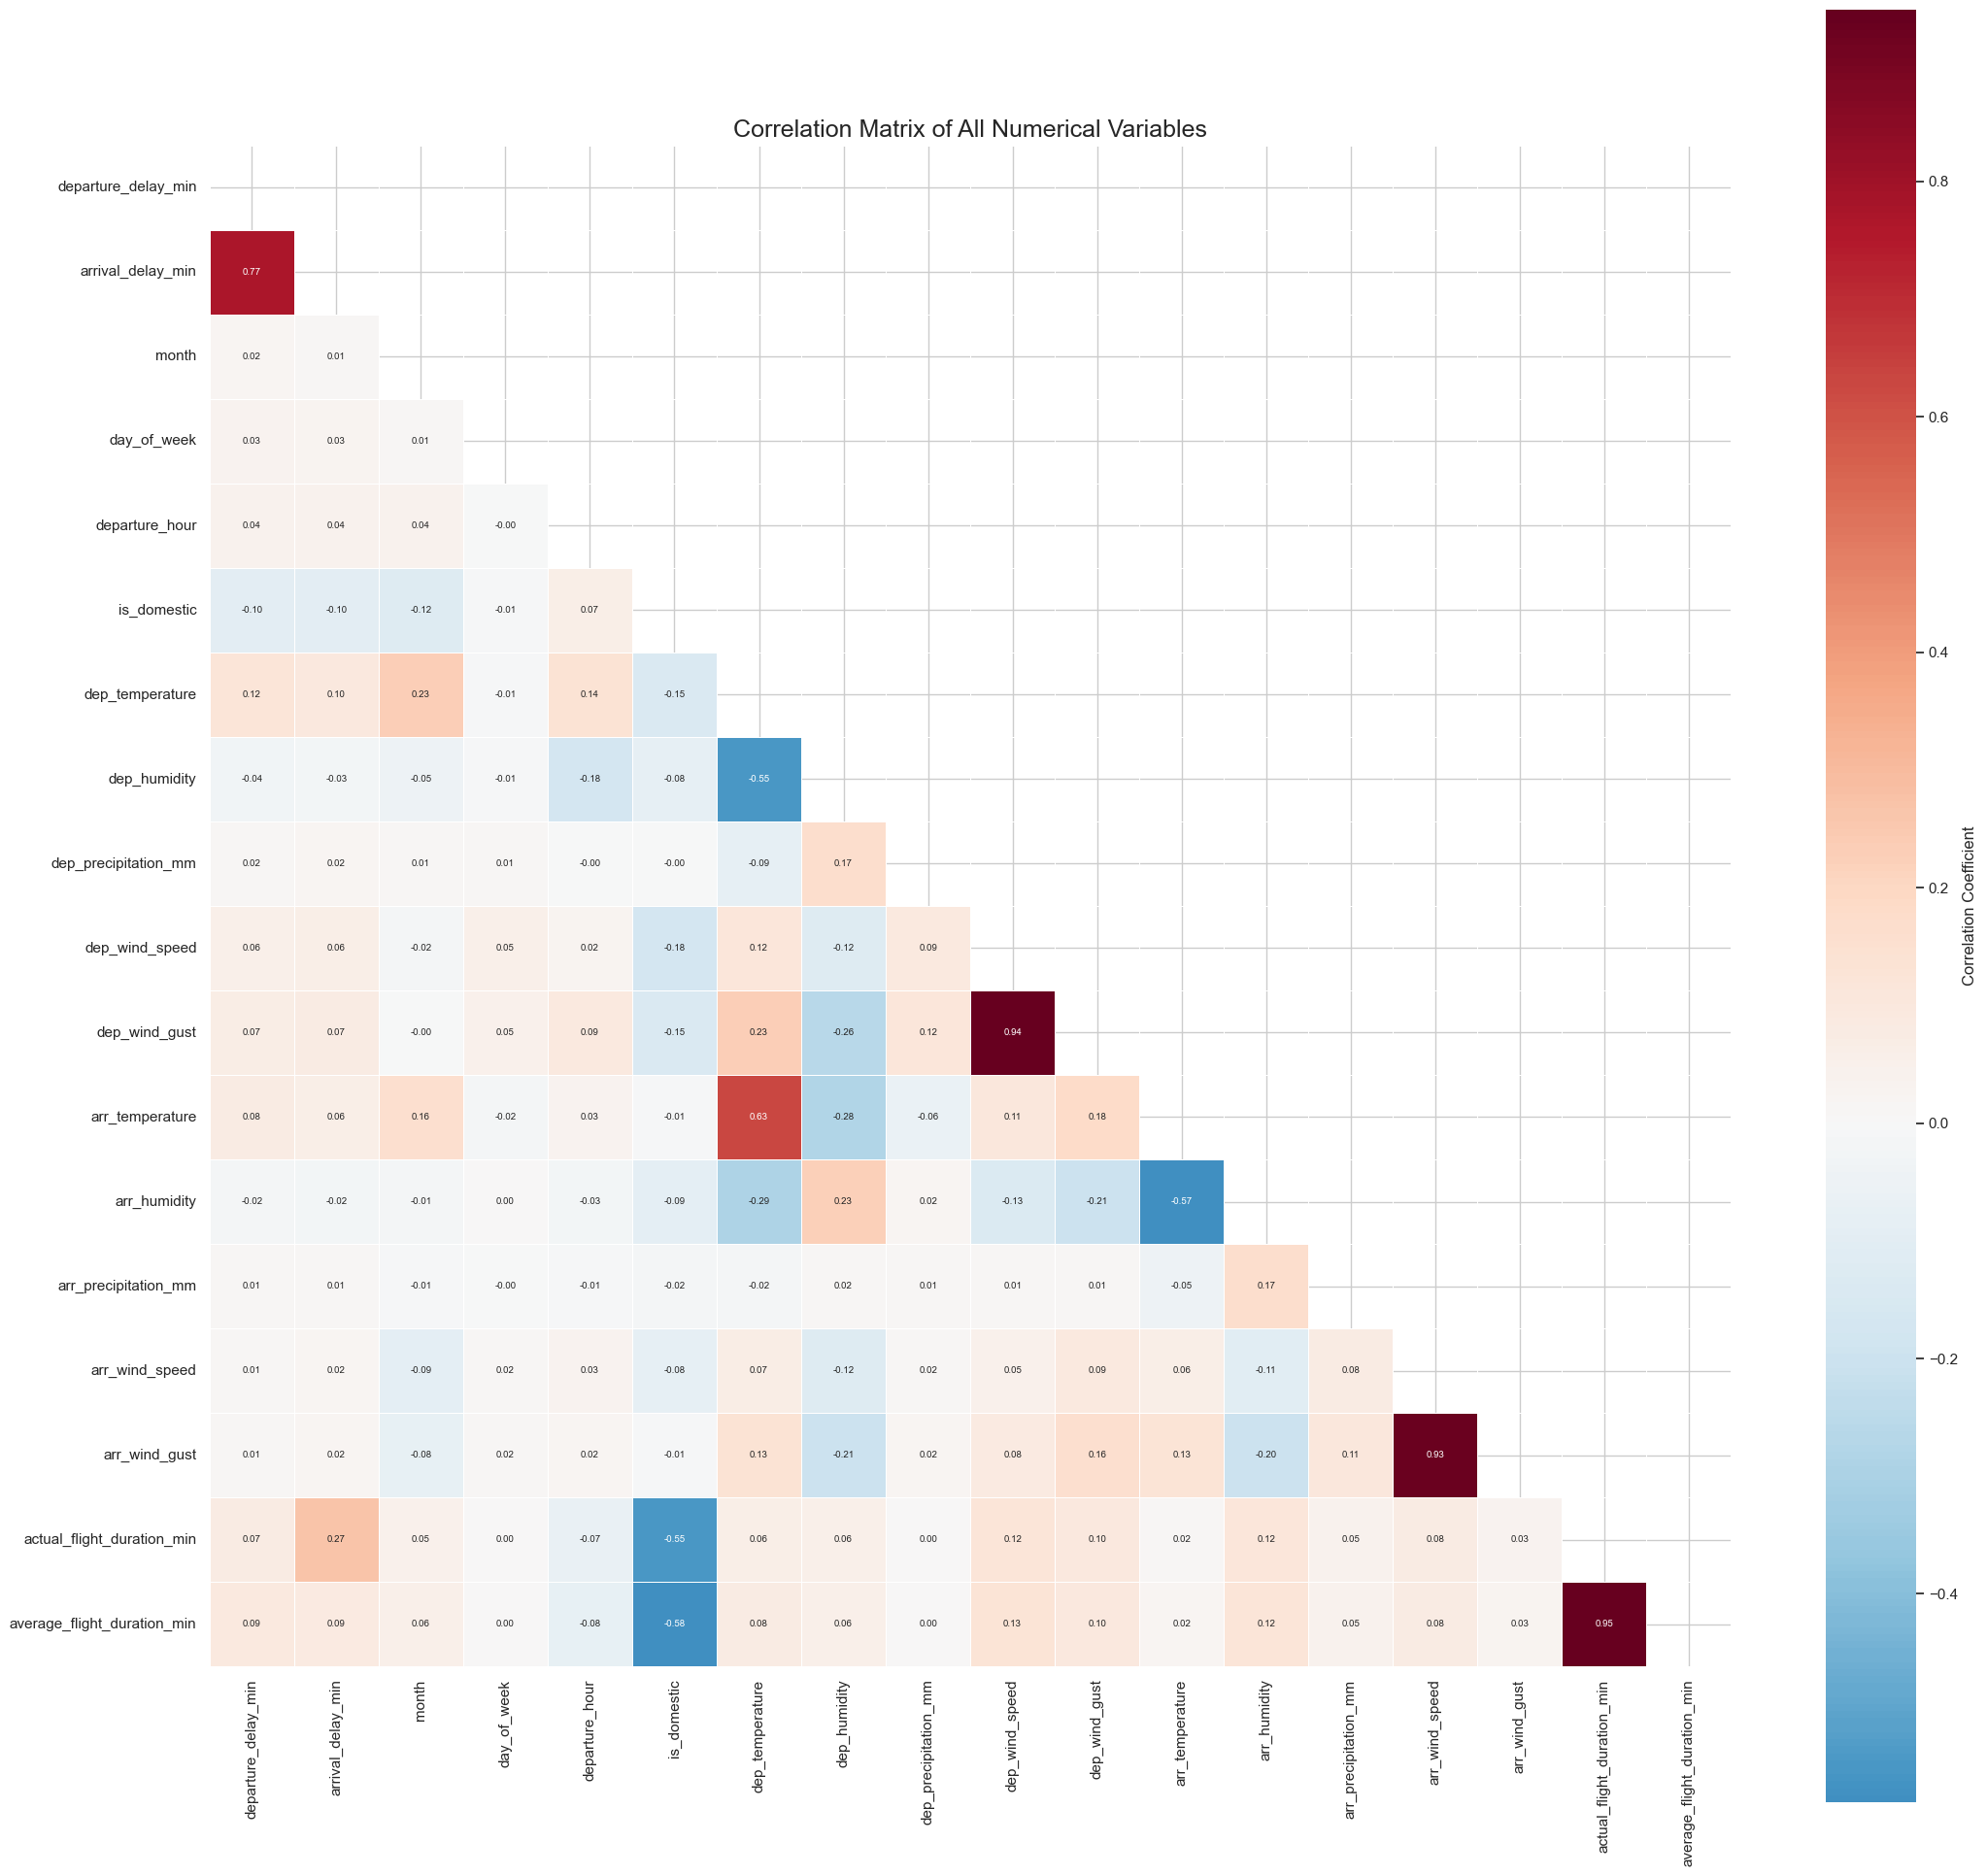


Top correlations with departure_delay_min:
arrival_delay_min              0.769130
dep_temperature                0.123099
is_domestic                    0.095415
average_flight_duration_min    0.094738
arr_temperature                0.077341
actual_flight_duration_min     0.072397
dep_wind_gust                  0.070370
dep_wind_speed                 0.059176
departure_hour                 0.039418
dep_humidity                   0.035148
Name: departure_delay_min, dtype: float64


In [10]:
# Correlation Matrix
corr_cols = [
    'departure_delay_min', 'arrival_delay_min', 'month', 'day_of_week', 'departure_hour', 'is_domestic',
    'dep_temperature', 'dep_humidity', 'dep_precipitation_mm', 'dep_wind_speed', 'dep_wind_gust', 
    'arr_temperature', 'arr_humidity', 'arr_precipitation_mm', 'arr_wind_speed', 'arr_wind_gust', 
    'actual_flight_duration_min', 'average_flight_duration_min'
]

# Calculate correlation matrix

corr_matrix = completed_flights_df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(22, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'}, annot_kws={'size': 7})
plt.title('Correlation Matrix of All Numerical Variables', fontsize=18)
plt.tight_layout()
plt.show()

print("\nTop correlations with departure_delay_min:")
target_corr = corr_matrix['departure_delay_min'].drop('departure_delay_min').abs().sort_values(ascending=False)
print(target_corr.head(10))

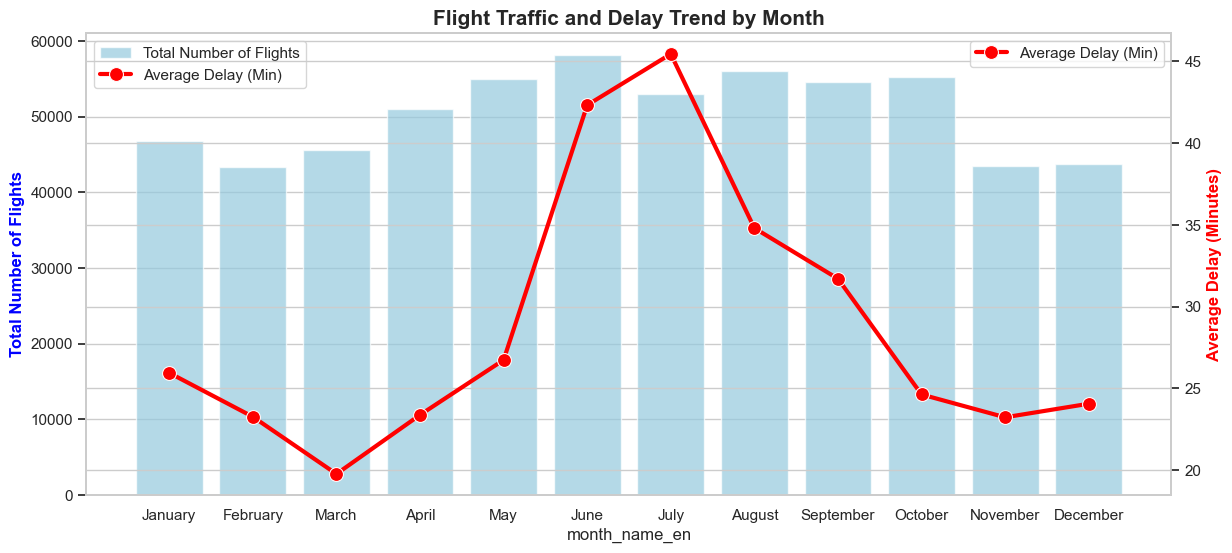

In [11]:
import matplotlib.pyplot as plt
import seaborn as pd
import pandas as pd
import calendar

completed_flights_df['month_name_en'] = completed_flights_df['date'].dt.month_name()
month_order = list(calendar.month_name)[1:]
completed_flights_df['month_name_en'] = pd.Categorical(completed_flights_df['month_name_en'], categories=month_order, ordered=True)

monthly_flights = completed_flights_df['month_name_en'].value_counts().sort_index()
monthly_delays = completed_flights_df.groupby('month_name_en', observed=True)['departure_delay_min'].mean()

plt.figure(figsize=(14, 6))

ax1 = plt.gca()
ax2 = ax1.twinx()

import seaborn as sns

sns.barplot(x=monthly_flights.index, y=monthly_flights.values, ax=ax1, color="skyblue", alpha=0.7, label="Total Number of Flights")
sns.lineplot(x=monthly_delays.index, y=monthly_delays.values, ax=ax2, color="red", marker="o", linewidth=3, markersize=10, label="Average Delay (Min)")

ax1.set_ylabel('Total Number of Flights', color="blue", fontweight='bold')
ax2.set_ylabel('Average Delay (Minutes)', color="red", fontweight='bold')
plt.title('Flight Traffic and Delay Trend by Month', fontsize=15, fontweight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

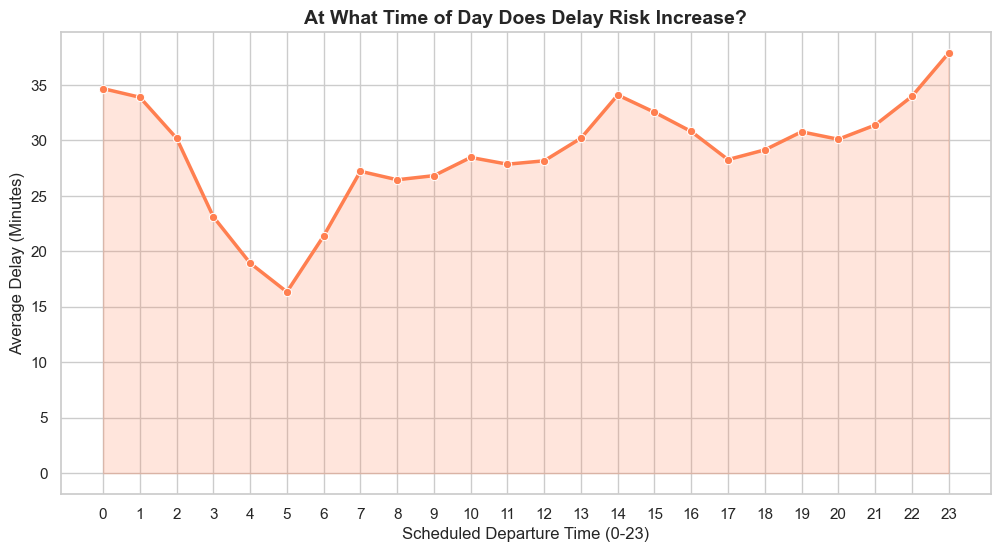

In [12]:
# At What Time of Day Does Delay Risk Increase?
plt.figure(figsize=(12, 6))
hourly_delay = completed_flights_df.groupby('departure_hour')['departure_delay_min'].mean()
sns.lineplot(x=hourly_delay.index, y=hourly_delay.values, marker="o", color="coral", linewidth=2.5)
plt.title('At What Time of Day Does Delay Risk Increase?', fontsize=14, fontweight='bold')
plt.xlabel('Scheduled Departure Time (0-23)')
plt.ylabel('Average Delay (Minutes)')
plt.xticks(range(0, 24))
plt.fill_between(hourly_delay.index, hourly_delay.values, alpha=0.2, color="coral") 
plt.show()


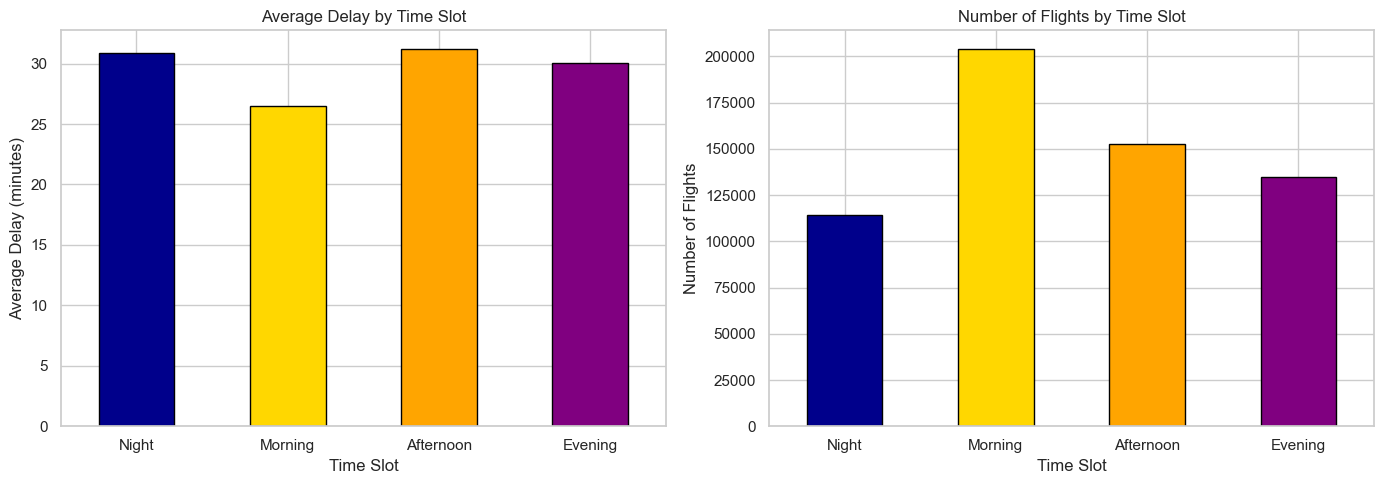

In [13]:
# Delay by Time Slot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average delay
time_slot_order = ['Night', 'Morning', 'Afternoon', 'Evening']
time_slot_delay = completed_flights_df.groupby('time_slot')['departure_delay_min'].mean().reindex(time_slot_order)
colors = ['darkblue', 'gold', 'orange', 'purple']
time_slot_delay.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_xlabel('Time Slot')
axes[0].set_ylabel('Average Delay (minutes)')
axes[0].set_title('Average Delay by Time Slot')
axes[0].tick_params(axis='x', rotation=0)

# Number of flights
time_slot_count = completed_flights_df.groupby('time_slot').size().reindex(time_slot_order)
time_slot_count.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_xlabel('Time Slot')
axes[1].set_ylabel('Number of Flights')
axes[1].set_title('Number of Flights by Time Slot')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

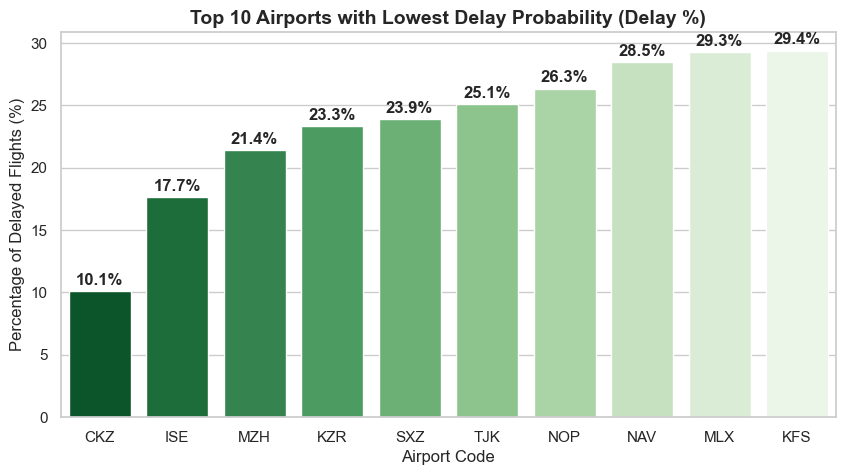

In [14]:
# Top 10 Airports with Lowest Delay Probability
completed_flights_df['is_delayed'] = completed_flights_df['departure_delay_min'] > 15
airport_delays = completed_flights_df.groupby('departure_airport').agg(
    total_flights=('is_delayed', 'count'),
    delayed_flights=('is_delayed', 'sum')
)
airport_delays = airport_delays[airport_delays['total_flights'] > 50] 
airport_delays['delay_percentage'] = (airport_delays['delayed_flights'] / airport_delays['total_flights']) * 100

best_airports = airport_delays.sort_values('delay_percentage').head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=best_airports.index, y=best_airports['delay_percentage'], hue=best_airports.index, palette="Greens_r", legend=False)
plt.title('Top 10 Airports with Lowest Delay Probability (Delay %)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Delayed Flights (%)')
plt.xlabel('Airport Code')
for i, v in enumerate(best_airports['delay_percentage']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()


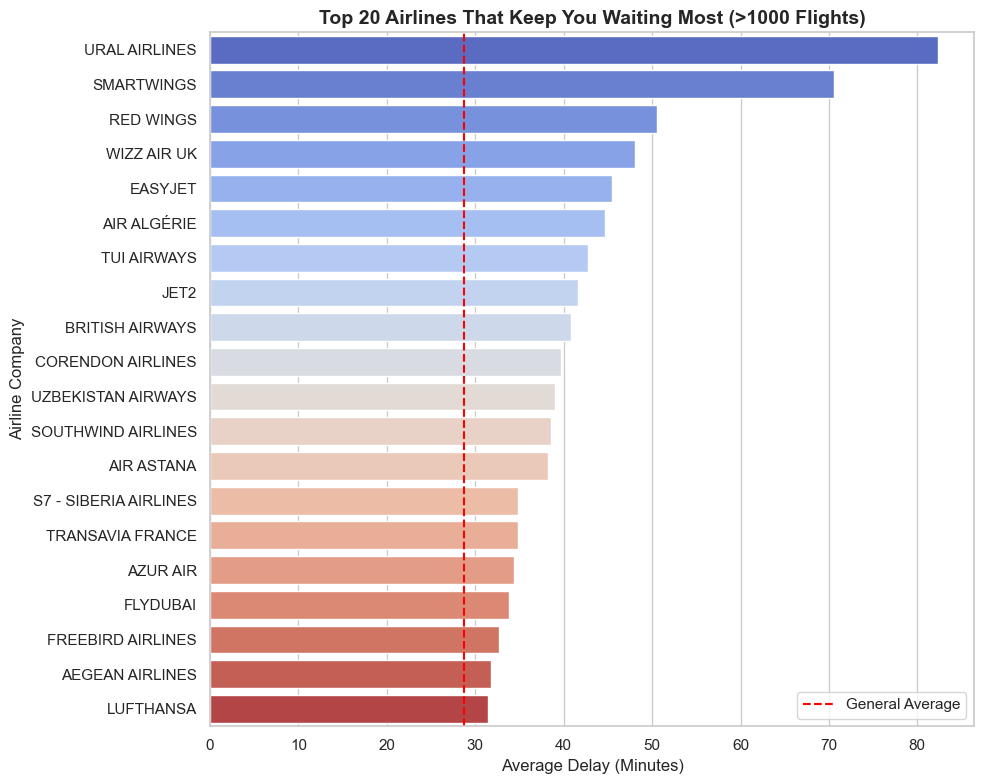

In [15]:
# Airlines That Keep You Waiting Most (>1000 Flights)
plt.figure(figsize=(10, 8))
airline_flight_counts = completed_flights_df['airline'].value_counts()
major_airlines = airline_flight_counts[airline_flight_counts > 1000].index
filtered_df = completed_flights_df[completed_flights_df['airline'].isin(major_airlines)]
avg_delay = filtered_df.groupby('airline')['departure_delay_min'].mean().sort_values(ascending=False).head(20)

sns.barplot(x=avg_delay.values, y=avg_delay.index, hue=avg_delay.index, palette="coolwarm", legend=False)
plt.title('Top 20 Airlines That Keep You Waiting Most (>1000 Flights)', fontsize=14, fontweight='bold')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Airline Company')
plt.axvline(x=filtered_df['departure_delay_min'].mean(), color='red', linestyle='--', label='General Average') 
plt.legend()
plt.tight_layout()
plt.show()

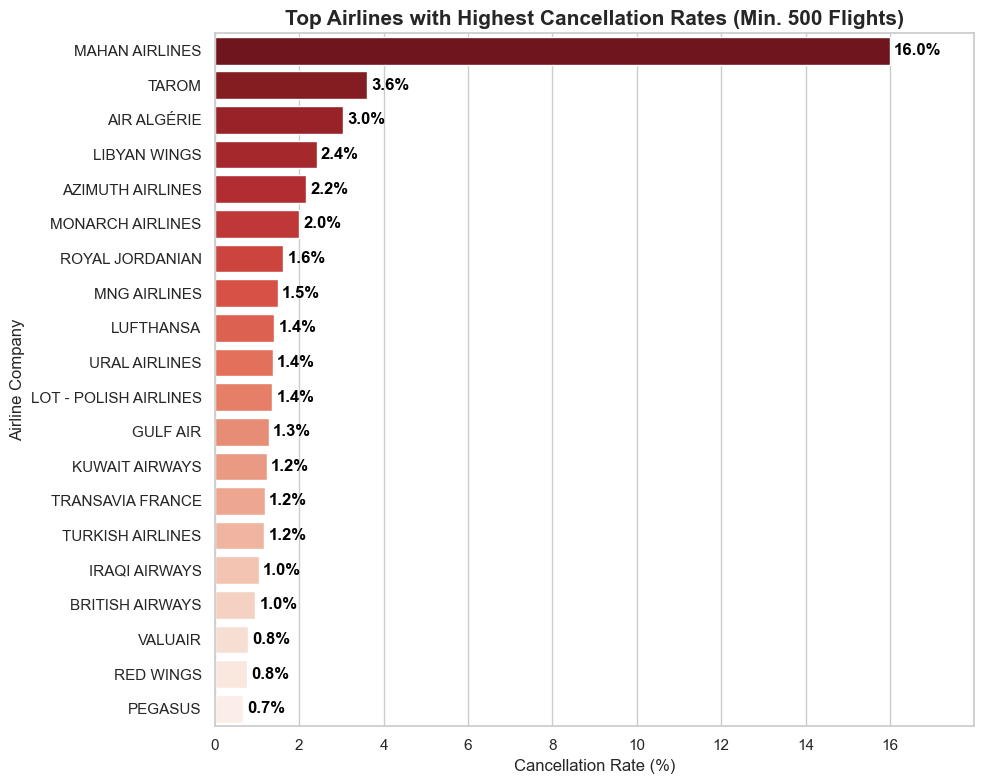

In [16]:
# Top Airlines with Highest Cancellation Rates
plt.figure(figsize=(10, 8))
airline_cancellations = df.groupby('airline').agg(
    total_flights=('is_cancelled', 'count'),
    cancelled_flights=('is_cancelled', 'sum')
)
airline_cancellations = airline_cancellations[airline_cancellations['total_flights'] >= 500]
airline_cancellations['cancel_percentage'] = (airline_cancellations['cancelled_flights'] / airline_cancellations['total_flights']) * 100
top_cancellations = airline_cancellations.sort_values('cancel_percentage', ascending=False).head(20)

sns.barplot(x=top_cancellations['cancel_percentage'], y=top_cancellations.index, 
            hue=top_cancellations.index, palette="Reds_r", legend=False)
plt.title('Top Airlines with Highest Cancellation Rates (Min. 500 Flights)', fontsize=15, fontweight='bold')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Airline Company')
for i, v in enumerate(top_cancellations['cancel_percentage']):
    plt.text(v + 0.1, i, f"{v:.1f}%", va='center', fontweight='bold', color='black')
plt.xlim(0, top_cancellations['cancel_percentage'].max() + 2) 
plt.tight_layout()
plt.show()


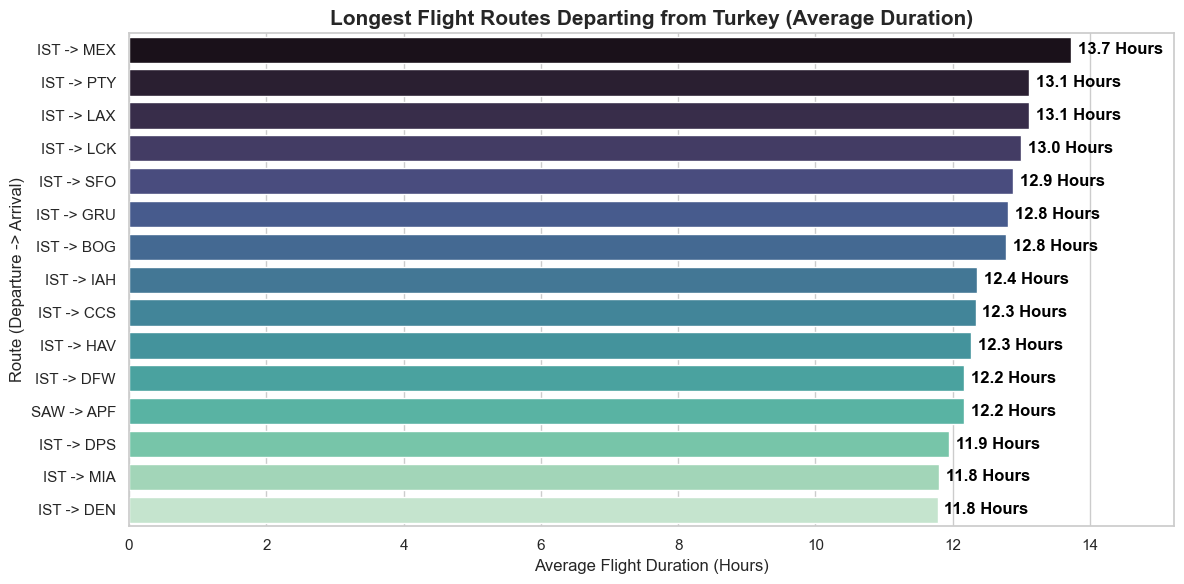

In [17]:
# Longest Flight Routes Departing from Turkey
plt.figure(figsize=(12, 6))

normal_durations = completed_flights_df[completed_flights_df['actual_flight_duration_min'] < 1440]
route_durations = normal_durations.groupby('route')['actual_flight_duration_min'].mean().sort_values(ascending=False).head(15)
route_durations_hours = route_durations / 60

sns.barplot(x=route_durations_hours.values, y=route_durations_hours.index, hue=route_durations_hours.index, palette="mako", legend=False)
plt.title('Longest Flight Routes Departing from Turkey (Average Duration)', fontsize=15, fontweight='bold')
plt.xlabel('Average Flight Duration (Hours)')
plt.ylabel('Route (Departure -> Arrival)')
for i, v in enumerate(route_durations_hours.values):
    plt.text(v + 0.1, i, f"{v:.1f} Hours", va='center', fontweight='bold', color='black')
plt.xlim(0, route_durations_hours.max() + 1.5) 
plt.tight_layout()
plt.show()


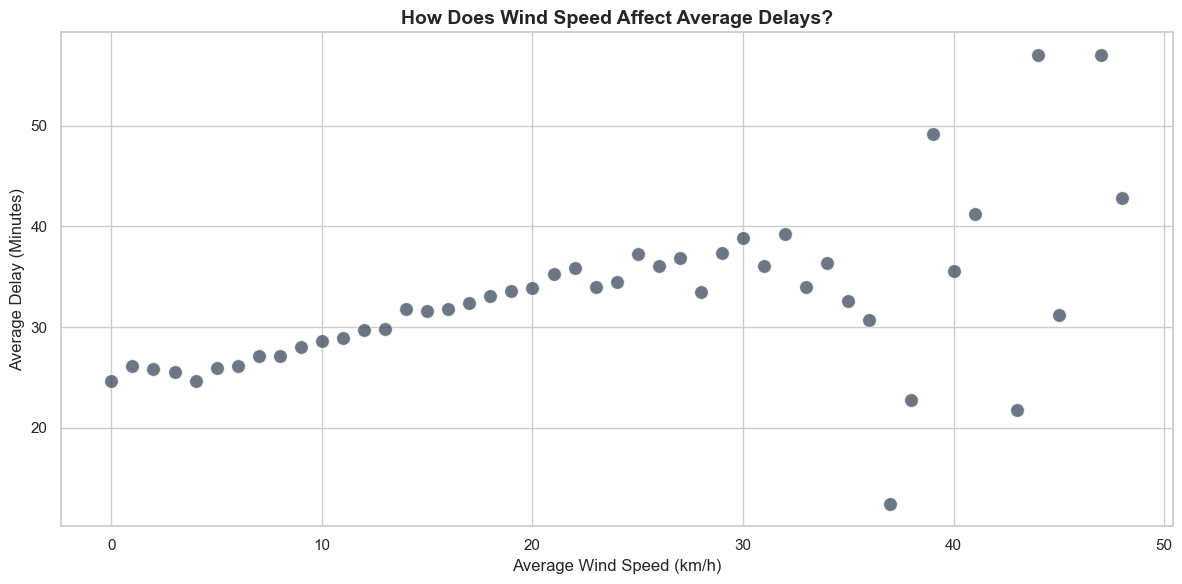

In [18]:
# How Does Wind Speed Affect Average Delays?
plt.figure(figsize=(12, 6))
completed_flights_df['rounded_wind'] = completed_flights_df['dep_wind_speed'].round()
wind_impact = completed_flights_df.groupby('rounded_wind')['departure_delay_min'].mean()
wind_impact = wind_impact[wind_impact.index < 50] 

sns.scatterplot(x=wind_impact.index, y=wind_impact.values, s=100, alpha=0.7, color='#2c3e50', edgecolor='white')
plt.title('How Does Wind Speed Affect Average Delays?', fontsize=14, fontweight='bold')
plt.xlabel('Average Wind Speed (km/h)')
plt.ylabel('Average Delay (Minutes)')
plt.tight_layout()
plt.show()


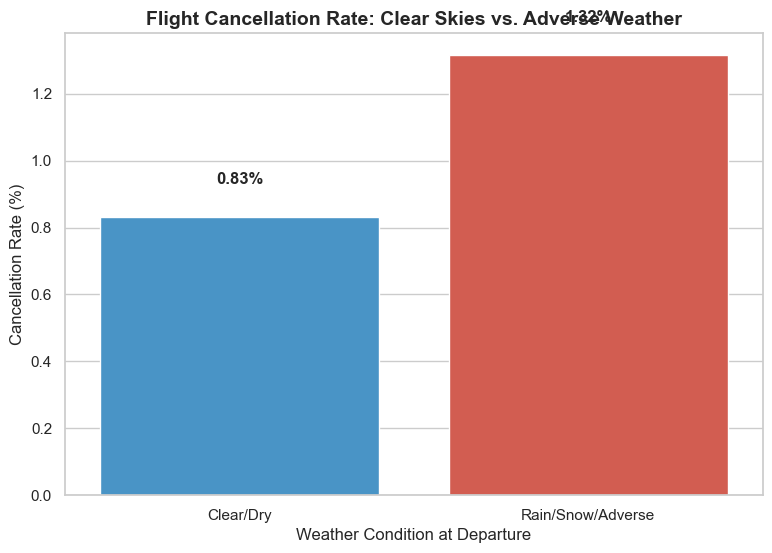

In [19]:
# Flight Cancellation Rate: Clear Skies vs. Adverse Weather
plt.figure(figsize=(9, 6))
df['weather_condition'] = np.where(df['dep_precipitation_mm'] > 0, 'Rain/Snow/Adverse', 'Clear/Dry')
cancel_rate_precip = df.groupby('weather_condition')['is_cancelled'].mean() * 100

sns.barplot(x=cancel_rate_precip.index, y=cancel_rate_precip.values, 
            hue=cancel_rate_precip.index, palette=["#3498db", "#e74c3c"], legend=False)
plt.title('Flight Cancellation Rate: Clear Skies vs. Adverse Weather', fontsize=14, fontweight='bold')
plt.xlabel('Weather Condition at Departure')
plt.ylabel('Cancellation Rate (%)')
for i, v in enumerate(cancel_rate_precip.values):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)
plt.show()


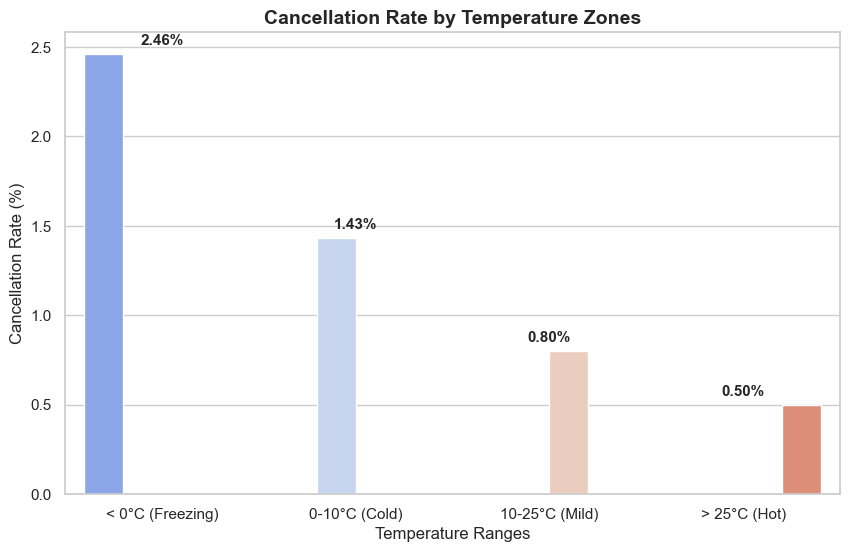

In [20]:
# Cancellation Rate by Temperature Zones
plt.figure(figsize=(10, 6))
df['temp_bin'] = pd.cut(df['dep_temperature'], 
                        bins=[-50, 0, 10, 25, 50], 
                        labels=['< 0°C (Freezing)', '0-10°C (Cold)', '10-25°C (Mild)', '> 25°C (Hot)'])

temp_cancel = df.groupby('temp_bin', observed=True)['is_cancelled'].mean() * 100

sns.barplot(x=temp_cancel.index, y=temp_cancel.values, hue=temp_cancel.index, palette="coolwarm", legend=False)
plt.title('Cancellation Rate by Temperature Zones', fontsize=14, fontweight='bold')
plt.xlabel('Temperature Ranges')
plt.ylabel('Cancellation Rate (%)')
for i, v in enumerate(temp_cancel.values):
    if not pd.isna(v):
        plt.text(i, v + 0.05, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)
plt.show()


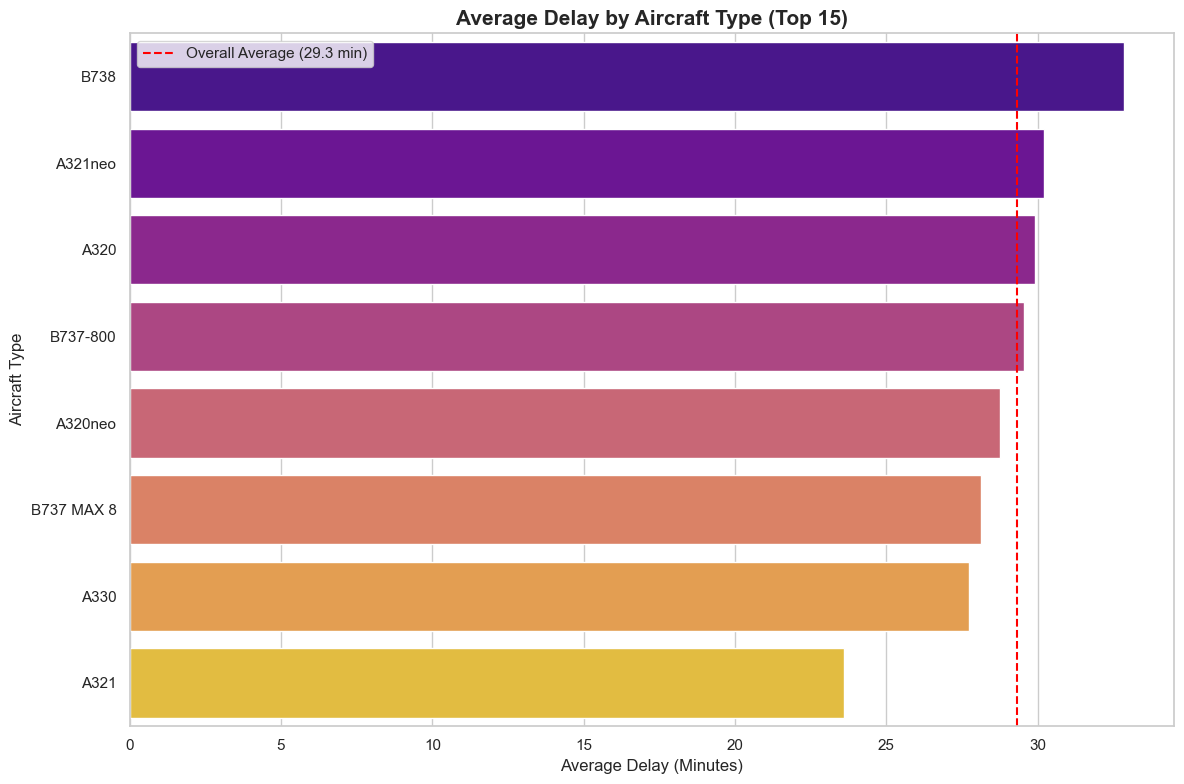

In [21]:
# Average Delay by Aircraft Type
plt.figure(figsize=(12, 8))
aircraft_counts = completed_flights_df['aircraft_type'].value_counts()
major_aircraft = aircraft_counts[aircraft_counts > 50].index
filtered_aircraft_df = completed_flights_df[completed_flights_df['aircraft_type'].isin(major_aircraft)]
avg_delay_aircraft = filtered_aircraft_df.groupby('aircraft_type')['departure_delay_min'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=avg_delay_aircraft.values, y=avg_delay_aircraft.index, hue=avg_delay_aircraft.index, palette="plasma", legend=False)
plt.title('Average Delay by Aircraft Type (Top 15)', fontsize=15, fontweight='bold')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Aircraft Type')
overall_avg = completed_flights_df['departure_delay_min'].mean()
plt.axvline(x=overall_avg, color='red', linestyle='--', label=f'Overall Average ({overall_avg:.1f} min)')
plt.legend()
plt.tight_layout()
plt.show()


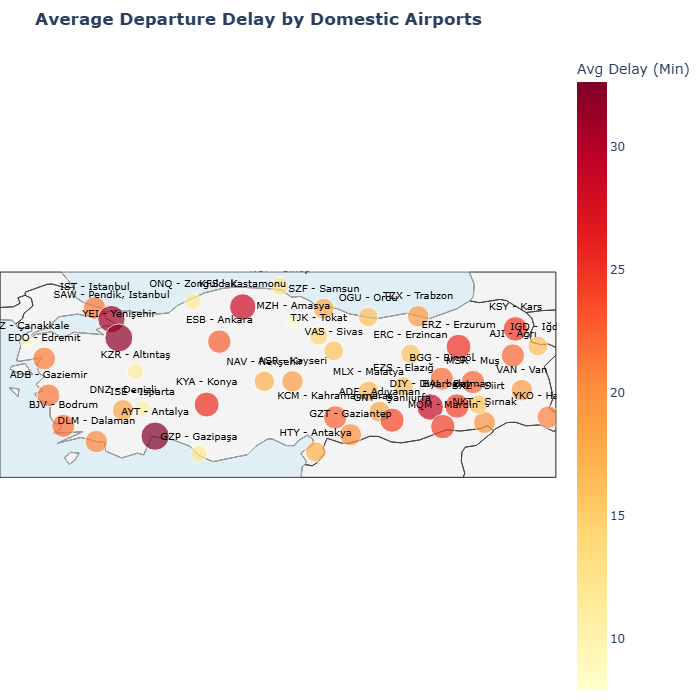

In [22]:
import plotly.express as px
import pandas as pd
import json
import plotly.io as pio
pio.renderers.default = "png" 

with open('global_airports.json', 'r', encoding='utf-8') as f:
    airport_coords = json.load(f)
coord_df = pd.DataFrame.from_dict(airport_coords, orient='index')

dom_flights = completed_flights_df[completed_flights_df['is_domestic'] == 1]
tr_delays = dom_flights.groupby(['departure_airport', 'departure_city']).agg(
    total_flights=('departure_delay_min', 'count'),
    avg_delay=('departure_delay_min', 'mean')
).reset_index()

tr_delays = tr_delays[tr_delays['total_flights'] > 100]
tr_map_df = tr_delays.merge(coord_df, left_on='departure_airport', right_index=True)

tr_map_df['airport_label'] = tr_map_df['departure_airport'] + " - " + tr_map_df['departure_city']

fig = px.scatter_geo(
    tr_map_df, 
    lat='lat', 
    lon='lon', 
    size='avg_delay', 
    color='avg_delay',
    hover_name='airport_label',
    hover_data={'lat': False, 'lon': False, 'total_flights': True, 'avg_delay': ':.1f', 'departure_airport': False, 'departure_city': False},
    text='airport_label',
    title='<b>Average Departure Delay by Domestic Airports</b>',
    labels={'avg_delay': 'Avg Delay (Min)', 'total_flights': 'Total Flights'},
    color_continuous_scale='YlOrRd'
)

fig.update_traces(textposition='top center', textfont=dict(size=10, color='black'))

fig.update_geos(
    lataxis_range=[35.5, 42.5], lonaxis_range=[25.5, 44.5],
    showcoastlines=True, coastlinecolor="DarkGray",
    showland=True, landcolor="#f4f4f4",
    showocean=True, oceancolor="#e0eef5",
    showcountries=True
)

fig.update_layout(height=700, margin={"r":0,"t":50,"l":0,"b":0})
fig.show(renderer="png")

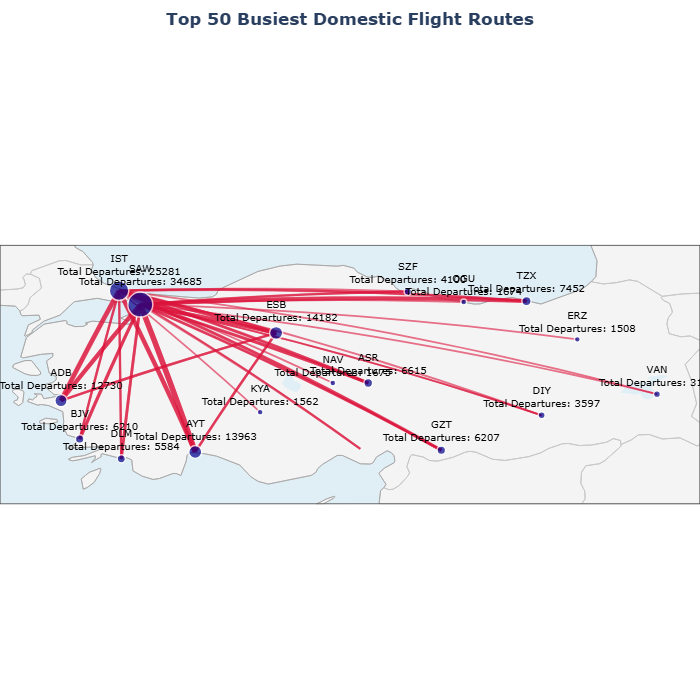

In [23]:
import plotly.graph_objects as go
import pandas as pd
pio.renderers.default = "png"

tr_flights = completed_flights_df[completed_flights_df['is_domestic'] == 1].copy()
route_counts = tr_flights.groupby(['departure_airport', 'arrival_airport']).size().reset_index(name='flight_count')
route_counts = route_counts.sort_values('flight_count', ascending=False).head(50)

route_counts = route_counts.merge(coord_df, left_on='departure_airport', right_index=True)
route_counts.rename(columns={'lat': 'start_lat', 'lon': 'start_lon'}, inplace=True)
route_counts = route_counts.merge(coord_df, left_on='arrival_airport', right_index=True)
route_counts.rename(columns={'lat': 'end_lat', 'lon': 'end_lon'}, inplace=True)

fig = go.Figure()
max_flights = route_counts['flight_count'].max()

for i in range(len(route_counts)):
    flight_vol = route_counts['flight_count'].iloc[i]
    line_weight = (flight_vol / max_flights) * 5 + 0.5
    
    fig.add_trace(
        go.Scattergeo(
            lon=[route_counts['start_lon'].iloc[i], route_counts['end_lon'].iloc[i]],
            lat=[route_counts['start_lat'].iloc[i], route_counts['end_lat'].iloc[i]],
            mode='lines',
            line=dict(width=line_weight, color='crimson'),
            opacity=0.6,
            hoverinfo='text',
            text=f"Route: {route_counts['departure_airport'].iloc[i]} ✈️ {route_counts['arrival_airport'].iloc[i]}<br>Flights: {flight_vol}",
            showlegend=False
        )
    )

hubs = route_counts.groupby(['departure_airport', 'start_lat', 'start_lon'])['flight_count'].sum().reset_index()
max_hub_vol = hubs['flight_count'].max()

fig.add_trace(
    go.Scattergeo(
        lon=hubs['start_lon'],
        lat=hubs['start_lat'],
        hoverinfo='text',
        text=hubs['departure_airport'] + '<br>Total Departures: ' + hubs['flight_count'].astype(str),
        mode='markers+text',
        textposition='top center',
        textfont=dict(size=10, color='black'),
        marker=dict(
            size=(hubs['flight_count'] / max_hub_vol) * 20 + 5,
            color='darkblue',
            line=dict(width=1.5, color='white')
        ),
        showlegend=False
    )
)

fig.update_geos(
    lataxis_range=[35.5, 42.5], lonaxis_range=[25.5, 44.5],
    showcoastlines=True, coastlinecolor="DarkGray",
    showland=True, landcolor="#f4f4f4",
    showocean=True, oceancolor="#e0eef5",
    showlakes=True, lakecolor="#e0eef5",
    showcountries=True, countrycolor="#c8c8c8",
    resolution=50
)

fig.update_layout(
    title_text='<b>Top 50 Busiest Domestic Flight Routes</b>',
    title_x=0.5,
    height=700,
    margin={"r":0,"t":50,"l":0,"b":0},
    geo=dict(bgcolor='rgba(0,0,0,0)')
)

fig.show(renderer="png")

## 7. Key Findings
1- Time of Day Dependency: Flights mostly depart on time in the morning, but delays skyrocket as evening and night approach.

2- Airline & Route Variances: The airline you choose and your destination (domestic/international) significantly affect your chances of a delay.

3- Severe Weather Impact: Bad weather, like rain or freezing temperatures, nearly doubles the flight cancellation rate.

4- Delay Distribution: Most flights depart on time or with a slight delay, but when a delay happens, it can stretch for many hours.

The most useful features are departure hour, wind speed, airline, and the month of the flight.

We had to drop the "visibility" and "cloud cover" data because too much of it was missing.
